In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
from scipy.signal import savgol_filter
from sklearn.preprocessing import OneHotEncoder

import pathlib
import sys
project_root = pathlib.Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling import sim_func, sim_prf, model_fit, model_fit_nans

In [19]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_25_lowess_timeseries.csv')
# df = pd.read_csv(x).drop(columns=['Unnamed: 0', 'LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)'])
df = pd.read_csv(x).dropna()
df

,condition,id,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),LDX_lowess,LDY_lowess,RDX_lowess,RDY_lowess
0,ACP,ACP_10,objet,negative,0.000000,0.041475,12.574262,-0.767978,9.236503,1.983911,12.603723,3.450543,8.745252
1,ACP,ACP_10,objet,negative,1.000558,0.241475,11.974262,-1.567978,6.436503,1.991126,12.606841,3.403829,8.724673
2,ACP,ACP_10,objet,negative,2.001117,-0.158525,5.374262,-1.367978,5.436503,1.997769,12.609701,3.356562,8.703663
3,ACP,ACP_10,objet,negative,3.001675,0.041475,10.374262,0.032022,7.636503,2.003828,12.612299,3.308732,8.682214
4,ACP,ACP_10,objet,negative,4.002233,-0.558525,12.174262,0.032022,7.036503,2.009291,12.614634,3.260330,8.660316
...,...,...,...,...,...,...,...,...,...,...,...,...,...
924667,DFT,DFT_9,visage,positive,1787.997767,-31.112508,-20.429326,-23.756709,-26.483485,-32.867712,-25.156976,-28.077767,-28.674864
924668,DFT,DFT_9,visage,positive,1788.998325,-29.512508,-19.229326,-24.356709,-23.483485,-32.977027,-25.256431,-28.172568,-28.780666
924669,DFT,DFT_9,visage,positive,1789.998883,-30.312508,-22.029326,-25.156709,-23.483485,-33.085890,-25.355475,-28.267085,-28.886203
924670,DFT,DFT_9,visage,positive,1790.999442,-30.512508,-21.029326,-26.156709,-26.283485,-33.194305,-25.454111,-28.361319,-28.991475


In [20]:
curve_fitting = df.loc[:, ['id', 'condition', 'category', 'valence', 'time', 'RDX_lowess']].copy()

curve_fitting['D_0'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda y: model_fit(len(y), y, np.repeat([1.0, 0.4], [300, len(y)-300]))['D_0']
)

curve_fitting['D_1'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda y: model_fit(len(y), y, np.repeat([1.0, 0.4], [300, len(y)-300]))['D_1']
)

curve_fitting['t_0'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda y: model_fit(len(y), y, np.repeat([1.0, 0.4], [300, len(y)-300]))['t_0']
)

curve_fitting['tau_1'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda y: model_fit(len(y), y, np.repeat([1.0, 0.4], [300, len(y)-300]))['tau_1']
)

curve_fitting['tau_2'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda y: model_fit(len(y), y, np.repeat([1.0, 0.4], [300, len(y)-300]))['tau_2']
)


In [14]:
curve_fitting = curve_fitting.iloc[0::1792, :]
curve_fitting

,id,condition,category,valence,time,RDX_lowess,D_0,D_1,t_0,tau_1,tau_2
0,ACP_10,ACP,objet,negative,0.000000,3.450543,-4.017268,5.163431,68.058298,19.929099,365.601282
1792,ACP_10,ACP,objet,neutre,0.000000,2.443832,-10.693229,6.048903,133.037557,7.482088,137.239981
3584,ACP_10,ACP,objet,positive,0.000000,4.884050,-11.155874,6.868066,55.807777,17.151997,429.335658
5376,ACP_10,ACP,visage,negative,0.000000,3.790080,-11.385244,5.867606,92.627911,10.070803,316.900229
7168,ACP_10,ACP,visage,neutre,0.000000,6.843432,-9.921035,4.267200,117.650359,7.232809,178.954730
...,...,...,...,...,...,...,...,...,...,...,...
916344,DFT_9,DFT,objet,neutre,632.352875,-21.153635,-7.982903,4.327432,106.086495,17.709874,253.374036
918136,DFT_9,DFT,objet,positive,632.352875,-12.189665,2.754013,4.826095,137.217355,10.314509,177.284111
919928,DFT_9,DFT,visage,negative,632.352875,-14.838571,-3.769711,3.979306,88.745348,9.926631,235.434122
921720,DFT_9,DFT,visage,neutre,632.352875,-12.333060,-1.507451,6.997153,113.990175,17.113424,189.458460


In [15]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ohetransform = ohe.fit_transform(curve_fitting[['category', 'valence']])
curve_fitting = pd.concat([curve_fitting, ohetransform], axis=1)

In [16]:
curve_fitting = curve_fitting.drop(columns=['time', 'RDX_lowess', 'category', 'valence'])
curve_fitting

,id,condition,D_0,D_1,t_0,tau_1,tau_2,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,ACP_10,ACP,-4.017268,5.163431,68.058298,19.929099,365.601282,1.0,0.0,1.0,0.0,0.0
1792,ACP_10,ACP,-10.693229,6.048903,133.037557,7.482088,137.239981,1.0,0.0,0.0,1.0,0.0
3584,ACP_10,ACP,-11.155874,6.868066,55.807777,17.151997,429.335658,1.0,0.0,0.0,0.0,1.0
5376,ACP_10,ACP,-11.385244,5.867606,92.627911,10.070803,316.900229,0.0,1.0,1.0,0.0,0.0
7168,ACP_10,ACP,-9.921035,4.267200,117.650359,7.232809,178.954730,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
916344,DFT_9,DFT,-7.982903,4.327432,106.086495,17.709874,253.374036,1.0,0.0,0.0,1.0,0.0
918136,DFT_9,DFT,2.754013,4.826095,137.217355,10.314509,177.284111,1.0,0.0,0.0,0.0,1.0
919928,DFT_9,DFT,-3.769711,3.979306,88.745348,9.926631,235.434122,0.0,1.0,1.0,0.0,0.0
921720,DFT_9,DFT,-1.507451,6.997153,113.990175,17.113424,189.458460,0.0,1.0,0.0,1.0,0.0


In [17]:
curve_fitting.to_csv('2026_09_29_lowess_curvefit_variables.csv', index=False)

In [10]:
curve_fitting.head(5)

,id,condition,category,valence,time,RDX_lowess,D_0,D_1,t_0,tau_1,tau_2
0,ACP_10,ACP,objet,negative,0.0,3.450543,-4.017268,5.163431,68.058298,19.929099,365.601282
1792,ACP_10,ACP,objet,neutre,0.0,2.443832,-10.693229,6.048903,133.037557,7.482088,137.239981
3584,ACP_10,ACP,objet,positive,0.0,4.884050,-11.155874,6.868066,55.807777,17.151997,429.335658
5376,ACP_10,ACP,visage,negative,0.0,3.790080,-11.385244,5.867606,92.627911,10.070803,316.900229
7168,ACP_10,ACP,visage,neutre,0.0,6.843432,-9.921035,4.267200,117.650359,7.232809,178.954730


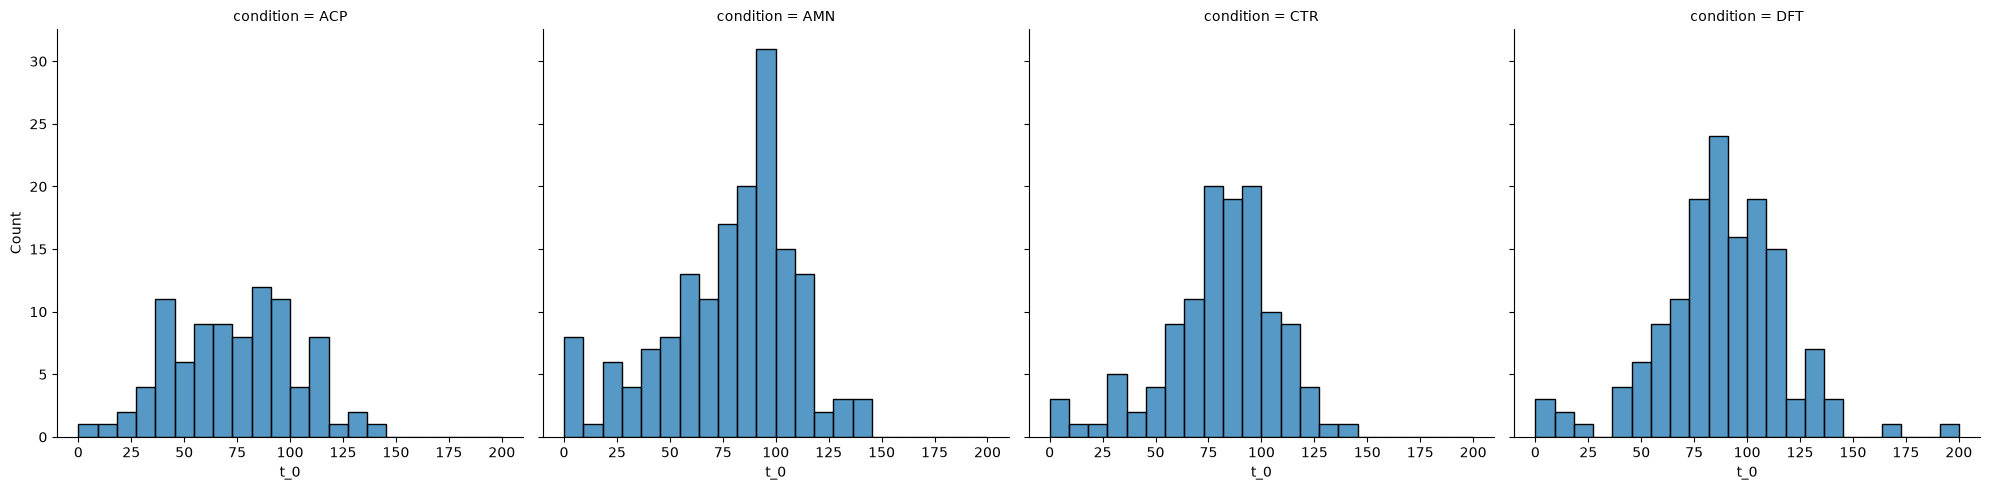

In [6]:
sns.displot(curve_fitting, x='t_0', col='condition', kind='hist')
plt.tight_layout()

<Axes: xlabel='valence', ylabel='tau_2'>

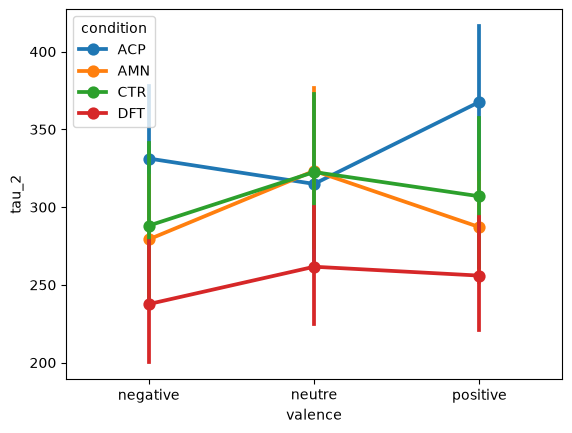

In [14]:
sns.pointplot(curve_fitting, x='valence', y='tau_2', hue='condition')

In [3]:
# weight = np.repeat([1.0, 0.4], [300, len])

curve_fitting = df.loc[:, ['id', 'condition', 'category', 'valence', 'time', 'RDX_lowess']]

curve_fitting['fit_timeseries'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda y: model_fit(len(y), y, np.repeat([1.0, 0.4], [300, len(y)-300]))
)



# # weight = np.repeat([1.0, 0.4], [300, len])

# curve_fitting = df.loc[:, ['condition_id', 'condition', 'category', 'valence', 'time', 'RDX_rolling']]

# curve_fitting['fit_timeseries'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
#     lambda y: model_fit(len(y), y, np.repeat([1.0, 0.4], [300, len(y)-300]))
# )

In [6]:
curve_fitting

,id,condition,category,valence,time,RDX_lowess,fit_timeseries,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,ACP_10,ACP,objet,negative,0.000000,3.450543,-4.017268,-38.864128,433,-8.395714,1749,0.023152
1,ACP_10,ACP,objet,negative,1.000558,3.403829,-4.017268,-38.864128,433,-8.395714,1749,0.023152
2,ACP_10,ACP,objet,negative,2.001117,3.356562,-4.017268,-38.864128,433,-8.395714,1749,0.023152
3,ACP_10,ACP,objet,negative,3.001675,3.308732,-4.017268,-38.864128,433,-8.395714,1749,0.023152
4,ACP_10,ACP,objet,negative,4.002233,3.260330,-4.017268,-38.864128,433,-8.395714,1749,0.023152
...,...,...,...,...,...,...,...,...,...,...,...,...
924667,DFT_9,DFT,visage,positive,1787.997767,-28.077767,-11.115931,-43.899137,282,-11.131458,1749,0.022337
924668,DFT_9,DFT,visage,positive,1788.998325,-28.172568,-11.115560,-43.899137,282,-11.131458,1749,0.022337
924669,DFT_9,DFT,visage,positive,1789.998883,-28.267085,-11.115190,-43.899137,282,-11.131458,1749,0.022337
924670,DFT_9,DFT,visage,positive,1790.999442,-28.361319,-11.114822,-43.899137,282,-11.131458,1749,0.022337


In [5]:
curve_fitting['RDX_min'] = curve_fitting.groupby(['id', 'category', 'valence'])['fit_timeseries'].transform(
    lambda x: x.iloc[50:600].min()
)

curve_fitting['RDX_lat_min'] = curve_fitting.groupby(['id', 'category', 'valence'])['fit_timeseries'].transform(
    lambda x: x.iloc[50:600].argmin() + 50 if x.notna().any() else None
)

curve_fitting['RDX_max'] = curve_fitting.groupby(['id', 'category', 'valence'])['fit_timeseries'].transform(
    lambda x: x.iloc[400:1750].max()
)

curve_fitting['RDX_lat_max'] = curve_fitting.groupby(['id', 'category', 'valence'])['fit_timeseries'].transform(
    lambda x: x.iloc[400:1750].argmax() + 400 if x.notna().any() else None
)

# # gradient of curve between 2 and 4 seconds
# curve_fitting['RDX_grad'] = curve_fitting.groupby(['id', 'category', 'valence'])['RDX_rolling'].transform(
#     lambda x: (x.iloc[1200]-x.iloc[300])/900 if x.notna().any() else None
# )

curve_fitting['RDX_grad'] = (curve_fitting.RDX_max - curve_fitting.RDX_min)/(curve_fitting.RDX_lat_max - curve_fitting.RDX_lat_min)

In [7]:
ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ohetransform = ohe.fit_transform(curve_fitting[['category', 'valence']])
curve_fitting = pd.concat([curve_fitting, ohetransform], axis=1)

In [9]:
curve_fitting = curve_fitting.iloc[::1792].drop(columns=['time', 'category', 'valence', 'RDX_lowess', 'fit_timeseries'])



In [25]:
sns.relplot(curve_fitting, x='time', y='fit_timeseries', hue='valence', style='category', col='id', col_wrap=4, kind='line', errorbar=None)

plt.tight_layout()

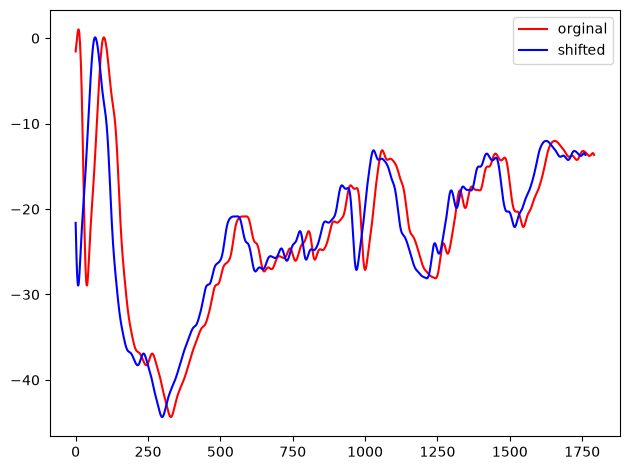

In [36]:
timeseries = df['RDX_rolling'].iloc[1792*0:1792*1]

plt.plot(timeseries, c='r', label='orginal')
plt.plot(timeseries.shift(-30), c='b', label='shifted')

plt.legend()
plt.tight_layout()
plt.show()

In [51]:
df['RDX_shifted'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x - x.shift(-30)
)

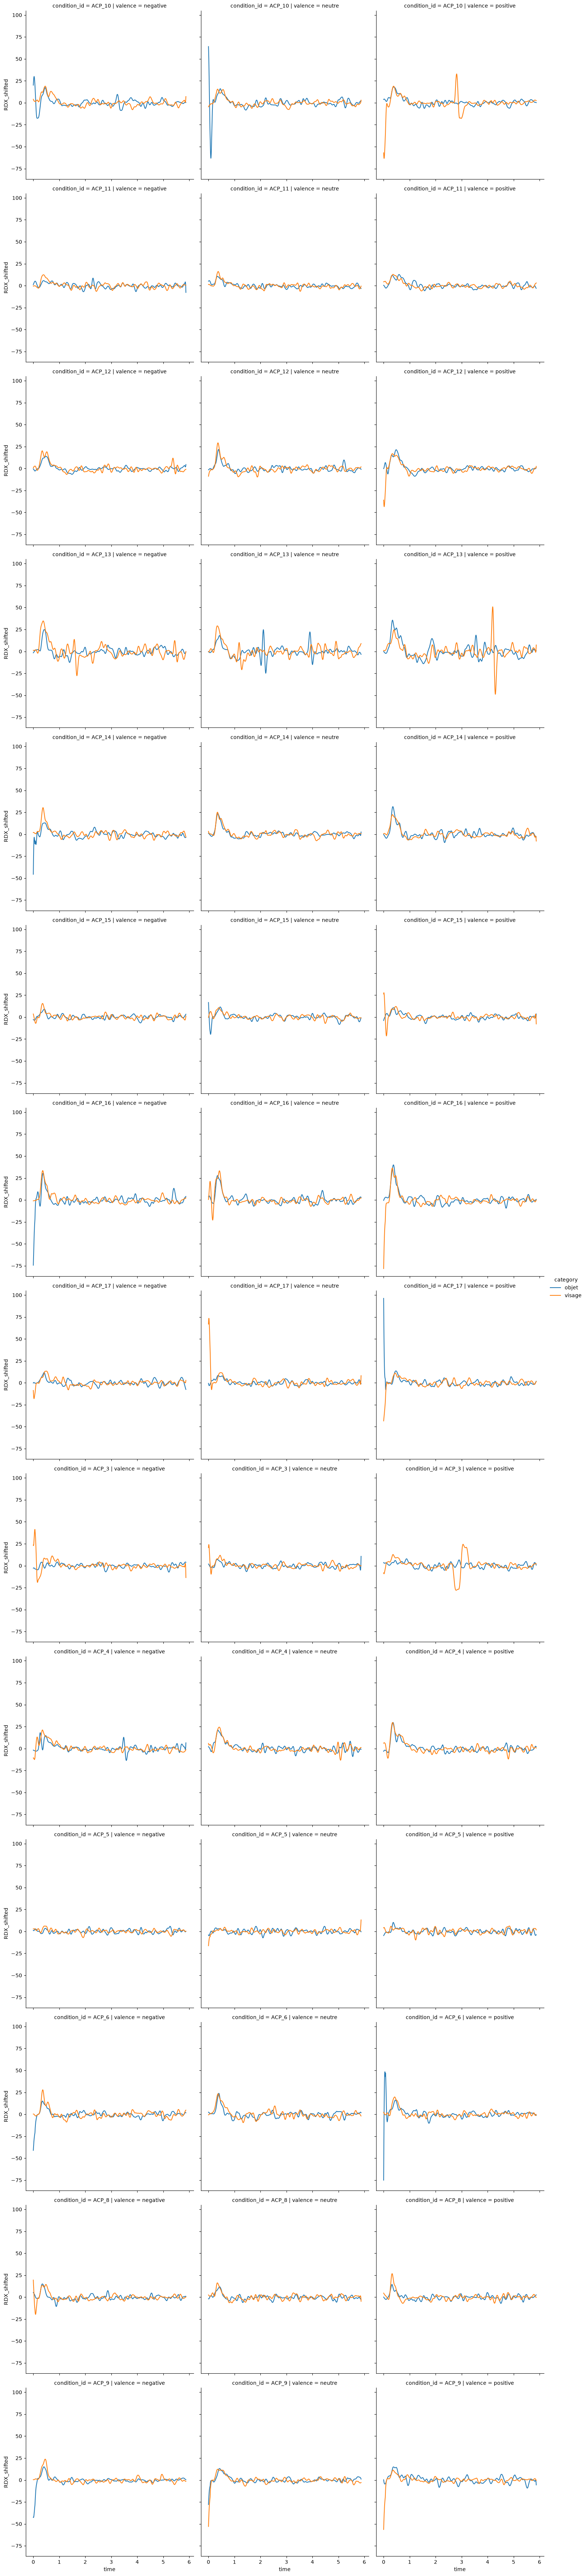

In [52]:
sns.relplot(df[df.condition=='ACP'], x='time', y='RDX_shifted', hue='category', col='valence', row='condition_id', kind='line', errorbar=None)

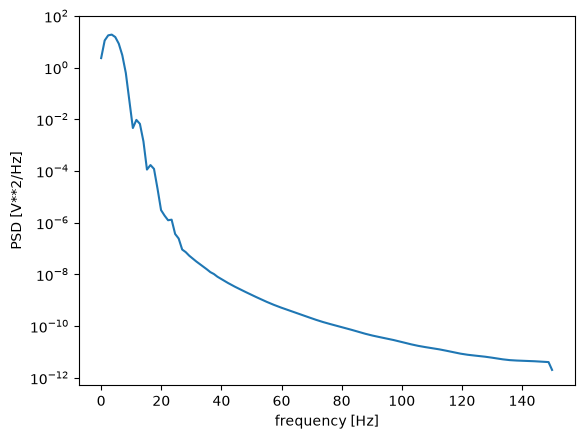

In [155]:
import scipy.signal as signal

x = np.array(df['RDX_shifted'][(df.condition_id=='ACP_13') & (df.valence=='positive') & (df.category=='visage')].dropna())
fs=300

f, Pxx_den = signal.welch(x, fs)
plt.semilogy(f, Pxx_den)
plt.ylim([0.5e-12, 1e+2])
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

In [119]:
f[Pxx_den.argmax()]

np.float64(3.515625)

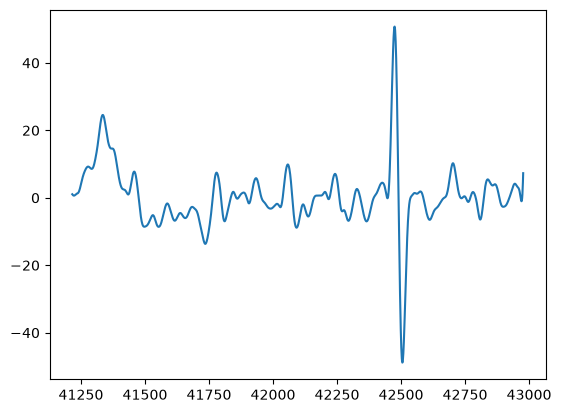

In [99]:
plt.plot(df['RDX_shifted'][(df.condition_id=='ACP_13') & (df.valence=='positive') & (df.category=='visage')].dropna())